## Modelowanie szeregu czasowego dla cen akcji
Ten notatnik pokazuje przykładowy przepływ pracy dla modelu uczącego się przewidywać ceny akcji.
1. Wczytanie danych
2. Wstępny przegląd informacji
3. Przygotowanie danych
4. Konstrukcja cech wejściowych
5. Uczenie sieci
6. Sprawdzenie jakości wyników

### Załadowanie narzędzi

In [1]:
# pakiety wykorzystywane w przykładzie
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["figure.figsize"] = (14, 7)
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"


2026-03-08 20:15:22.756864: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Zmienność rynku i wpływ zdarzeń zewnętrznych - przykład WIG20 w okresie pandemii

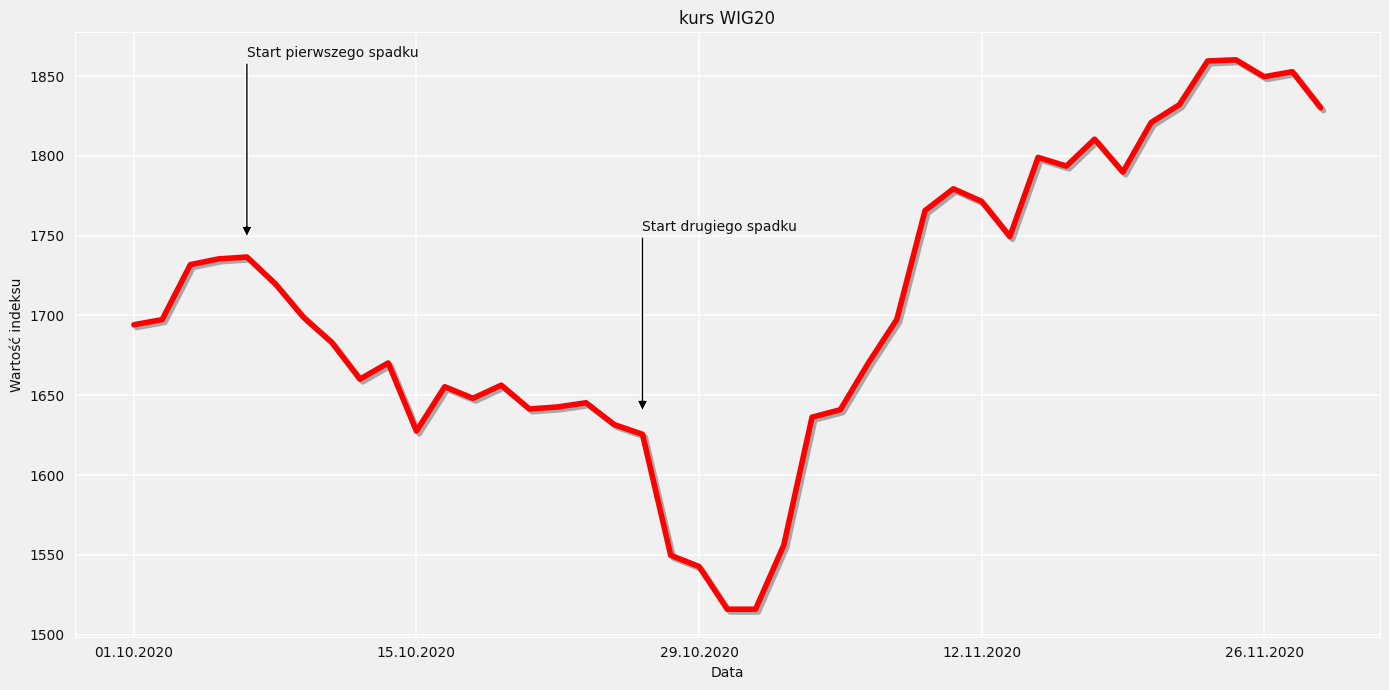

In [2]:
import matplotlib.patheffects as path_effects

dates_wig20 = [
    "01.10.2020",
    "02.10.2020",
    "05.10.2020",
    "06.10.2020",
    "07.10.2020",
    "08.10.2020",
    "09.10.2020",
    "12.10.2020",
    "13.10.2020",
    "14.10.2020",
    "15.10.2020",
    "16.10.2020",
    "19.10.2020",
    "20.10.2020",
    "21.10.2020",
    "22.10.2020",
    "23.10.2020",
    "26.10.2020",
    "27.10.2020",
    "28.10.2020",
    "29.10.2020",
    "30.10.2020",
    "01.11.2020",
    "02.11.2020",
    "03.11.2020",
    "04.11.2020",
    "05.11.2020",
    "06.11.2020",
    "09.11.2020",
    "10.11.2020",
    "12.11.2020",
    "13.11.2020",
    "16.11.2020",
    "17.11.2020",
    "18.11.2020",
    "19.11.2020",
    "20.11.2020",
    "23.11.2020",
    "24.11.2020",
    "25.11.2020",
    "26.11.2020",
    "27.11.2020",
    "30.11.2020",
]

wig20_values = [
    1694.18,
    1697.39,
    1731.85,
    1735.45,
    1736.61,
    1719.91,
    1698.91,
    1683.21,
    1660.12,
    1670.26,
    1627.59,
    1655.36,
    1648.11,
    1656.34,
    1641.42,
    1642.7,
    1645.32,
    1631.66,
    1625.54,
    1549.74,
    1542.76,
    1515.97,
    1515.97,
    1556.14,
    1636.28,
    1640.94,
    1670.43,
    1697.49,
    1765.71,
    1779.34,
    1771.49,
    1749.41,
    1799.02,
    1793.56,
    1810.43,
    1789.79,
    1820.85,
    1832.04,
    1859.42,
    1860.15,
    1849.57,
    1852.69,
    1830.04,
]

wig20_frame = pd.DataFrame({"WIG20": wig20_values}, index=dates_wig20)

chart, axis = plt.subplots(figsize=(14, 7))
axis.set_facecolor("#f0f0f0")
chart.patch.set_facecolor("#f0f0f0")

axis.grid(True, color="white", linewidth=1.2, alpha=0.9)
axis.tick_params(colors="#111111")
axis.xaxis.label.set_color("#111111")
axis.yaxis.label.set_color("#111111")
axis.title.set_color("#111111")

wig20_series = wig20_frame["WIG20"]
wig20_series.plot(
    ax=axis,
    style="r-",
    linewidth=4,
    path_effects=[path_effects.SimpleLineShadow(), path_effects.Normal()],
)

# 07.10.2020 - decyzja o żółtej strefie w całym kraju + maseczki także na zewnątrz
# 27.10.2020 - cały kraj w czerwonej strefie + istotne zmiany w pracy szkół

axis.set_title("kurs WIG20")
axis.annotate(
    "Start pierwszego spadku",
    color="#111111",
    xy=(4, 1719 + 30),
    xytext=(4, 1719 + 150),
    arrowprops=dict(facecolor="black", headwidth=8, width=2, headlength=8),
    horizontalalignment="left",
    verticalalignment="top",
)

axis.annotate(
    "Start drugiego spadku",
    color="#111111",
    xy=(18, 1610 + 30),
    xytext=(18, 1610 + 150),
    arrowprops=dict(facecolor="black", headwidth=8, width=2, headlength=8),
    horizontalalignment="left",
    verticalalignment="top",
)

axis.set_xlabel("Data")
axis.set_ylabel("Wartość indeksu")

plt.tight_layout()
plt.show()


### Wczytanie pliku z danymi

In [3]:
stock_frame = pd.read_csv("../data/google.csv")

### Przegląd zbioru

In [4]:
stock_frame.describe()

,High,Low,Open,Close,Volume,Adj Close
count,4317.000000,4317.000000,4317.000000,4317.000000,4.317000e+03,4317.000000
mean,639.682936,627.615621,633.603748,633.852357,6.523837e+06,633.852357
std,561.783142,552.069438,556.527532,557.255541,7.830526e+06,557.255541
min,50.680038,47.800831,49.409801,49.818268,7.922000e+03,49.818268
25%,247.507278,241.469910,244.832306,244.334183,1.593563e+06,244.334183
50%,401.988251,395.168823,399.004425,398.561096,3.851583e+06,398.561096
75%,933.440002,923.030029,929.059998,928.799988,8.268878e+06,928.799988
max,2936.409912,2912.290039,2918.989990,2916.840088,8.254163e+07,2916.840088


In [5]:
stock_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4317 entries, 0 to 4316
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4317 non-null   object 
 1   High       4317 non-null   float64
 2   Low        4317 non-null   float64
 3   Open       4317 non-null   float64
 4   Close      4317 non-null   float64
 5   Volume     4317 non-null   float64
 6   Adj Close  4317 non-null   float64
dtypes: float64(6), object(1)
memory usage: 236.2+ KB


In [6]:
stock_frame.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2004-08-19,51.835709,47.800831,49.813290,49.982655,44871361.0,49.982655
1,2004-08-20,54.336334,50.062355,50.316402,53.952770,22942874.0,53.952770
2,2004-08-23,56.528118,54.321388,55.168217,54.495735,18342897.0,54.495735
3,2004-08-24,55.591629,51.591621,55.412300,52.239197,15319808.0,52.239197
4,2004-08-25,53.798351,51.746044,52.284027,52.802086,9232276.0,52.802086


## Przygotowanie cech wejściowych

In [7]:
# skalowanie wartości zamknięcia do zakresu 0-1
close_values = stock_frame.iloc[:, 3:4].values
value_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close_values = value_scaler.fit_transform(close_values)
scaled_close_values


array([[1.40608776e-04],
       [3.15935047e-04],
       [2.00670999e-03],
       ...,
       [9.50609507e-01],
       [9.57878900e-01],
       [9.57140076e-01]])

### Rozdzielenie próbek treningowych i testowych

In [8]:
train_sequences = []
train_targets = []
lookback_window = 70  # długość okna obserwacji

for row_idx in range(lookback_window, 3500):
    train_sequences.append(scaled_close_values[row_idx - lookback_window : row_idx, 0])
    train_targets.append(scaled_close_values[row_idx, 0])

train_sequences = np.array(train_sequences)
train_targets = np.array(train_targets)

test_sequences = []
test_targets = []

for row_idx in range(3501, 4300):
    test_sequences.append(scaled_close_values[row_idx - lookback_window : row_idx, 0])
    test_targets.append(scaled_close_values[row_idx, 0])

test_sequences = np.array(test_sequences)
test_targets = np.array(test_targets)


In [9]:
train_sequences = np.reshape(
    train_sequences,
    (train_sequences.shape[0], train_sequences.shape[1], 1),
)
test_sequences = np.reshape(
    test_sequences,
    (test_sequences.shape[0], test_sequences.shape[1], 1),
)


### Budowa sieci LSTM

In [10]:
# konstrukcja sieci LSTM do predykcji kolejnej wartości szeregu
price_forecaster = Sequential()
price_forecaster.add(LSTM(units=50, return_sequences=True))
price_forecaster.add(Dropout(0.2))
price_forecaster.add(LSTM(units=50, return_sequences=True))
price_forecaster.add(Dropout(0.2))
price_forecaster.add(LSTM(units=50, return_sequences=True))
price_forecaster.add(Dropout(0.2))
price_forecaster.add(LSTM(units=50))
price_forecaster.add(Dropout(0.2))
price_forecaster.add(Dense(units=1))
price_forecaster.compile(optimizer="adam", loss="mean_squared_error")


### Uczenie modelu

In [ ]:
price_forecaster.fit(train_sequences, train_targets, epochs=10, batch_size=32)

108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 2.1066e-04


### Generowanie predykcji dla części testowej

In [ ]:
forecast_scaled = price_forecaster.predict(test_sequences)
forecast_values = value_scaler.inverse_transform(forecast_scaled)
forecast_values


In [ ]:
# wartości obserwowane, użyte do porównania z predykcją
observed_values = value_scaler.inverse_transform(test_targets.reshape(-1, 1))
observed_values


### Zestawienie wartości rzeczywistych i przewidywanych

In [ ]:
plt.plot(observed_values, color="orange", label="observed price")
plt.plot(forecast_values, color="green", label="forecast price")
plt.title("Google stock price forecast")
plt.xlabel("time")
plt.ylabel("stock price")
plt.legend()
plt.show()


### Ocena rezultatów

In [ ]:
# podstawowe miary jakości modelu
print(f'RMSE {metrics.mean_squared_error(forecast_values, observed_values)}')
print(f'MAE {metrics.mean_absolute_error(forecast_values, observed_values)}')
